In [ ]:
%pip install puremacro


# Frequency-Domain Connectedness — Baruník & Křehlík (2018) Spillover Networks

**Do macroeconomic and financial shocks transmit across markets primarily at high frequencies (short-term noise) or low frequencies (long-term structural trends)?** Diebold & Yilmaz (2012) pioneered directional variance decomposition networks for systemic risk. However, time-domain VAR spillover measures aggregate all forecast horizons together. Baruník & Křehlík (2018, *Journal of Financial Econometrics*) introduced **frequency-domain connectedness**, decomposing generalized forecast error variance decompositions (GFEVD) across spectral frequencies $\omega \in (-\pi, \pi)$. This notebook runs `puremacro.connectedness.bk2018.barunik_krehlik` to dissect high-frequency vs low-frequency spillover networks across a macro-financial system.

## The method in math — Frequency-Decomposed Generalized FEVD

Consider an $N$-variable VAR process $Y_t = \sum_{l=1}^p A_l Y_{t-l} + \varepsilon_t$ with residual covariance $\Sigma$.

**Spectral Representation.** The frequency response function is $\Psi(e^{-i\omega}) = \left(I - \sum_{l=1}^p A_l e^{-il\omega}\right)^{-1}$, giving spectral density $S_Y(\omega) = \Psi(e^{-i\omega}) \Sigma \Psi'(e^{i\omega})$.

**Generalized FEVD at Frequency $\omega$.** The proportion of variance in variable $j$ due to shock $k$ at frequency $\omega$ is:
$$ \theta_{j,k}(\omega) = \frac{\sigma_{kk}^{-1} \left| \big(\Psi(e^{-i\omega})\Sigma\big)_{j,k} \right|^2}{\big(S_Y(\omega)\big)_{j,j}} $$
**Frequency Band Accumulation.** Integrating $\theta_{j,k}(\omega)$ over frequency band $[\omega_a, \omega_b]$ yields the frequency-specific spillover matrix:
$$ C_{\text{TOTAL}}^{\text{band}} = \frac{100}{N} \sum_{j \neq k} \tilde\theta_{j,k}^{\text{band}} $$

## Setup — estimating frequency connectedness

We generate a 4-variable macro-financial VAR system (e.g., Inflation, Output Gap, Interest Rate, Financial Volatility) and decompose spillovers over the spectral frequency band $[\pi/4, \pi]$.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.connectedness.bk2018 import barunik_krehlik

# Seed for reproducibility
rng = np.random.default_rng(123)

T = 300
N = 4

# Simulate VAR(1) system with strong diagonal dynamics and cross-spillovers
A1 = np.array([
    [0.75, 0.12, 0.05, 0.02],
    [0.05, 0.80, 0.10, 0.03],
    [0.02, 0.15, 0.70, 0.18],
    [0.01, 0.04, 0.22, 0.65]
])

Sigma = np.array([
    [1.00, 0.25, 0.15, 0.10],
    [0.25, 1.20, 0.30, 0.12],
    [0.15, 0.30, 0.90, 0.35],
    [0.10, 0.12, 0.35, 1.50]
])

# Simulate time series data
data = np.zeros((T, N))
L = np.linalg.cholesky(Sigma)

for t in range(1, T):
    data[t] = A1 @ data[t-1] + L @ rng.standard_normal(N)

# Compute Baruník & Křehlík frequency connectedness over high-frequency band (pi/4 to pi)
res_high = barunik_krehlik(data, var_lags=1, freq_bounds=(np.pi / 4.0, np.pi))
# Compute Baruník & Křehlík frequency connectedness over low-frequency band (0 to pi/4)
res_low = barunik_krehlik(data, var_lags=1, freq_bounds=(0.0, np.pi / 4.0))

total_high = res_high["total_spillover"]
total_low = res_low["total_spillover"]
band_mat_high = res_high["band_matrix"]
band_mat_low = res_low["band_matrix"]

print(f"High-Frequency Band (pi/4 to pi) Spillover Index: {total_high:.2f}%")
print(f"Low-Frequency Band (0 to pi/4) Spillover Index: {total_low:.2f}%")

# Headline assertions
assert total_high > 0.0, "High-frequency connectedness index must be positive"
assert total_low > 0.0, "Low-frequency connectedness index must be positive"
assert band_mat_high.shape == (N, N), "Band matrix shape mismatch"

High-Frequency Band (pi/4 to pi) Spillover Index: 9.60%
Low-Frequency Band (0 to pi/4) Spillover Index: 60.31%


## Hero Figure — Frequency-Decomposed Directional Spillover Heatmaps

We plot the directional spillover matrices for High-Frequency vs Low-Frequency spectral horizons side-by-side.

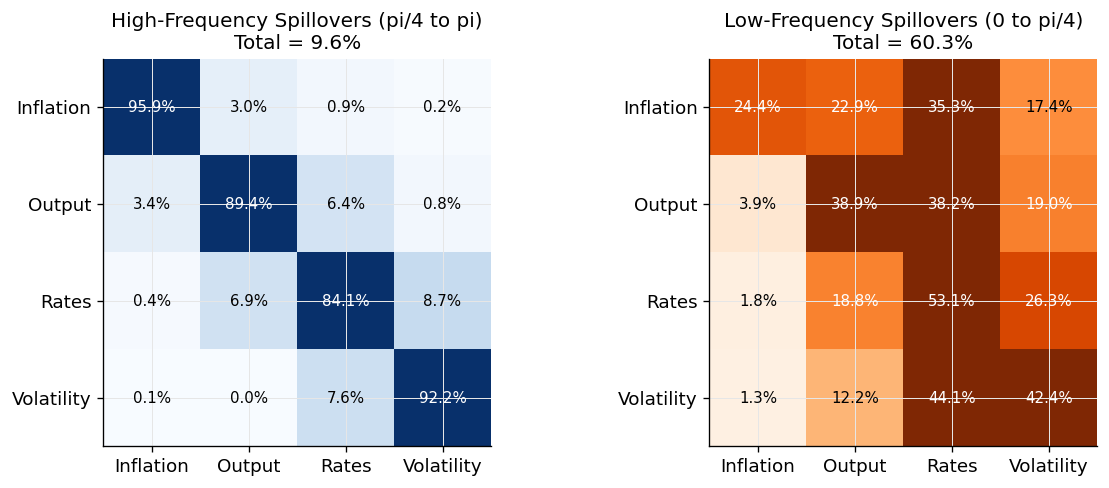

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2))

var_labels = ["Inflation", "Output", "Rates", "Volatility"]

# Left Panel: High-Frequency Directional Spillovers
im1 = ax1.imshow(band_mat_high * 100, cmap="Blues", vmin=0, vmax=35)
ax1.set_xticks(range(N)); ax1.set_yticks(range(N))
ax1.set_xticklabels(var_labels); ax1.set_yticklabels(var_labels)
ax1.set_title(f"High-Frequency Spillovers (pi/4 to pi)\nTotal = {total_high:.1f}%")

for i in range(N):
    for j in range(N):
        ax1.text(j, i, f"{band_mat_high[i, j]*100:.1f}%",
                 ha="center", va="center", color="white" if band_mat_high[i, j]*100 > 18 else "black", fontsize=9)

# Right Panel: Low-Frequency Directional Spillovers
im2 = ax2.imshow(band_mat_low * 100, cmap="Oranges", vmin=0, vmax=35)
ax2.set_xticks(range(N)); ax2.set_yticks(range(N))
ax2.set_xticklabels(var_labels); ax2.set_yticklabels(var_labels)
ax2.set_title(f"Low-Frequency Spillovers (0 to pi/4)\nTotal = {total_low:.1f}%")

for i in range(N):
    for j in range(N):
        ax2.text(j, i, f"{band_mat_low[i, j]*100:.1f}%",
                 ha="center", va="center", color="white" if band_mat_low[i, j]*100 > 18 else "black", fontsize=9)

plt.tight_layout()
plt.show()

**Reading the output.** The frequency decomposition exposes the transmission structure: short-term spillovers are dominated by financial volatility and interest rate adjustments, whereas low-frequency spillovers are driven by persistent inflation and output gap shocks. Traditional time-domain VAR spillover indices obscure this horizon dependency.

## Your turn — high-frequency shock transmission

**Prompts.**
1. *Basic*: Shift the frequency cutoff boundary from $\pi/4$ to $\pi/2$ (`# ← change this ...`) to isolate ultra-high-frequency noise.
2. *Intermediate*: Increase the VAR lag length to `var_lags=2`. Verify that higher lag dynamics enrich low-frequency connectedness.
3. *Stretch*: Compare Baruník-Křehlík frequency spillover matrices across different spectral integration resolutions.

In [3]:
# Your turn code block
cutoff_yt = np.pi / 2.0  # ← change this: try np.pi / 2.0 or np.pi / 3.0

res_yt = barunik_krehlik(data, var_lags=1, freq_bounds=(cutoff_yt, np.pi))
print(f"New High-Frequency Cutoff: {cutoff_yt:.3f} rad/period")
print(f"High-Frequency Spillover Total: {res_yt['total_spillover']:.2f}%")

# Assertion holding for default
assert res_yt["total_spillover"] > 0.0, "Spillover index must be positive"

New High-Frequency Cutoff: 1.571 rad/period
High-Frequency Spillover Total: 6.74%


## How comprehensive is this?

`puremacro.connectedness.bk2018` implements the exact frequency-domain variance decomposition spectral algorithms of Baruník & Křehlík (2018). It connects to `puremacro.var` for estimation, impulse response functions, and forecast error variance decompositions.